#### Bit depth

This is a small notebook that generates a figure which illustrates the relevance of bith depth.

In [6]:

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

# Generate a time series which varies ±5 around a value of 10
time_1 = np.arange(0, 100)
value_1 = 10 + 5 * np.sin(0.2 * time_1) + np.random.normal(0, 1, size=time_1.shape)

# Now generate a 2nd time series which varies ±1000 around a value of 10.000
time_2 = np.arange(100, 200)
value_2 = 10000 + 1000 * np.sin(0.2 * time_2) + np.random.normal(0, 50, size=time_2.shape)

# Paste together the two respective signals
time = np.concatenate([time_1, time_2])
value = np.concatenate([value_1, value_2])

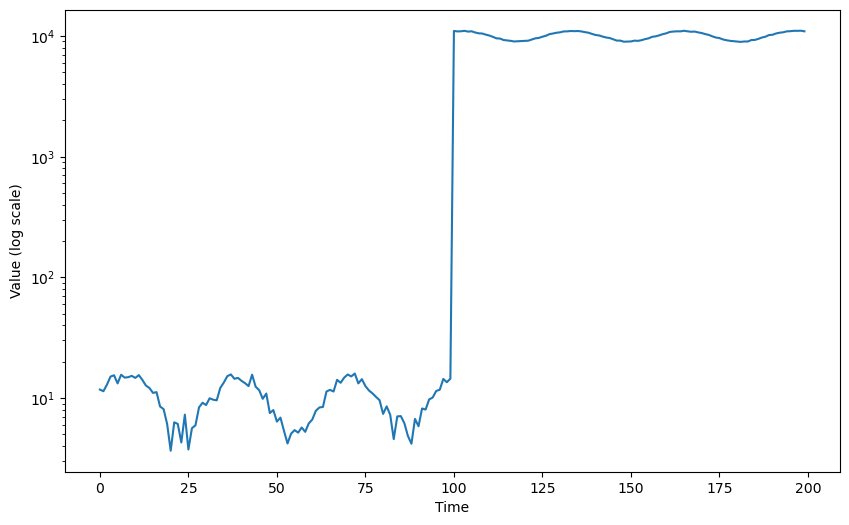

In [17]:
# Now plot on a logarithmic y-axis
def plot_mydata(time, value, ax):
    ax.plot(time, value, label='Time Series Data')
    ax.set_yscale('log')
    ax.set_xlabel('Time')
    ax.set_ylabel('Value (log scale)')
    
# Generate figure
fig, ax = plt.subplots(figsize=(10, 6))
plot_mydata(time, value, ax)

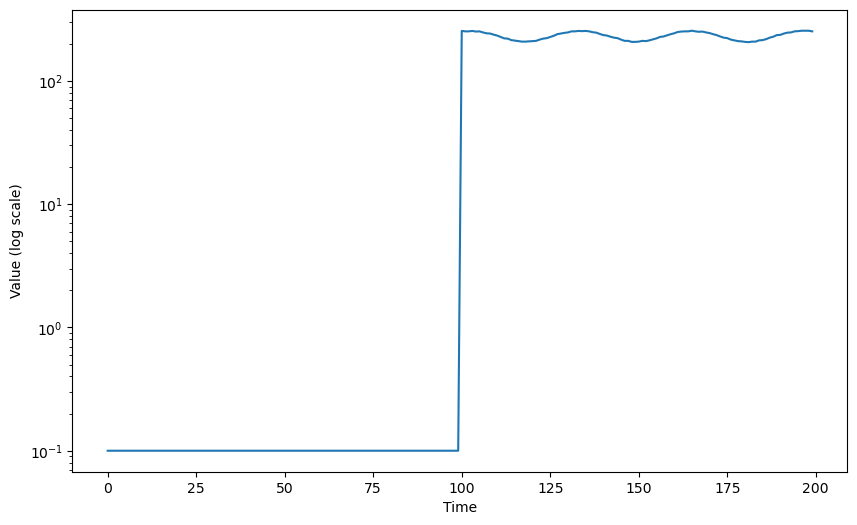

In [19]:
value_as_8bitint = np.clip(np.round((value - value.min()) / (value.max() - value.min()) * 255), 0, 255).astype(np.uint8)

# Now make the same plot again
fig, ax = plt.subplots(figsize=(10, 6))
plot_mydata(time, value_as_8bitint+.1, ax)

Text(0.5, 1.0, '8 bit format')

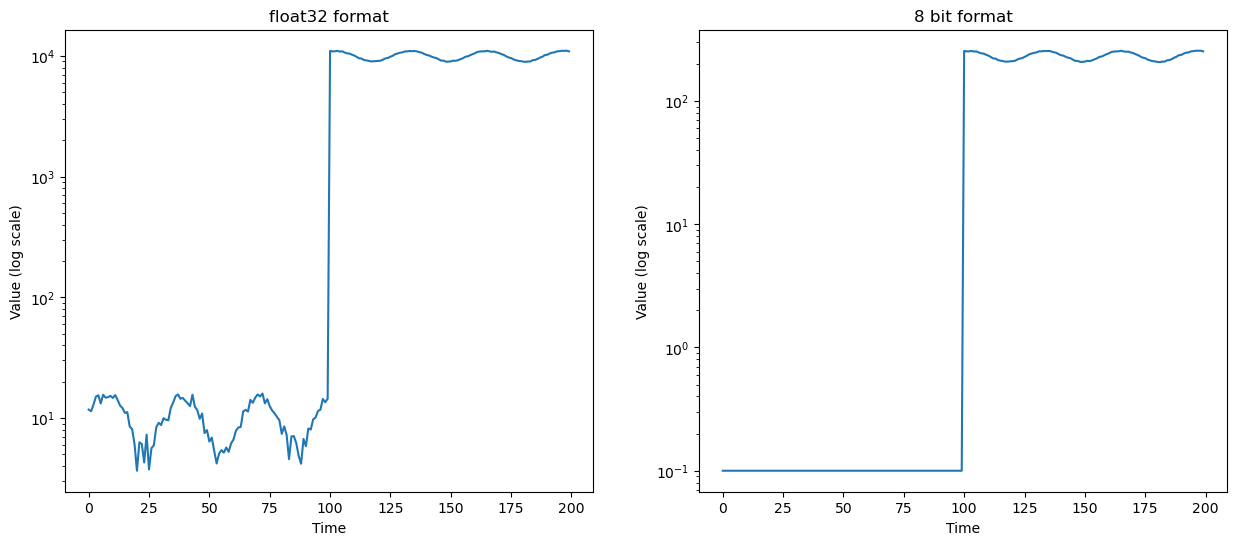

In [22]:
# now arrange those two figures next to each other
fig, axs = plt.subplots(1, 2, figsize=(15, 6))
plot_mydata(time, value, axs[0])
axs[0].set_title("float32 format")
plot_mydata(time, value_as_8bitint+.1, axs[1])
axs[1].set_title("8 bit format")